In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload('')

Saving Salary_Data.csv to Salary_Data (1).csv


In [62]:
df_sal = pd.read_csv('Salary_Data.csv')
df_sal.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [63]:
df_sal.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


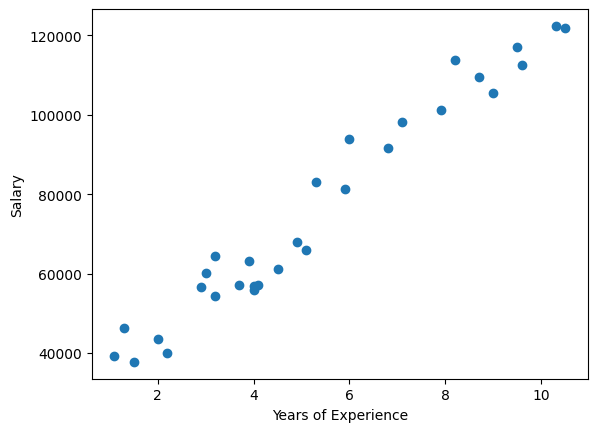

In [64]:
from re import X
plt.scatter(df_sal.YearsExperience, df_sal.Salary)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [65]:
#m = slope, b = bias/errpr, points = actual data points
def loss_function(m, b, points):
  totalError = 0
  for i in range(len(points)):
    x = points.iloc[i].YearsExperience
    y = points.iloc[i].Salary
    totalError += (y - (m * x + b))**2
  return totalError/float(len(points))


In [66]:
def gradient_descent(m_now, b_now, points, L):
  m_gradient = 0
  b_gradient = 0
  n = len(points)
  for i in range(n):
    x = points.iloc[i].YearsExperience
    y = points.iloc[i].Salary
    m_gradient += -(2/n) * x * (y - (m_now * x + b_now))
    b_gradient += -(2/n) * (y - (m_now * x + b_now))
  m = m_now - m_gradient * L
  b = b_now - b_gradient * L
  return m , b



In [133]:
m = 0
b = 0
L = 0.0001
epochs = 30000

In [134]:
for i in range(epochs):
  m, b = gradient_descent(m, b, df_sal, L)

In [135]:
print(m, b)

10445.31800702768 19084.76241710769


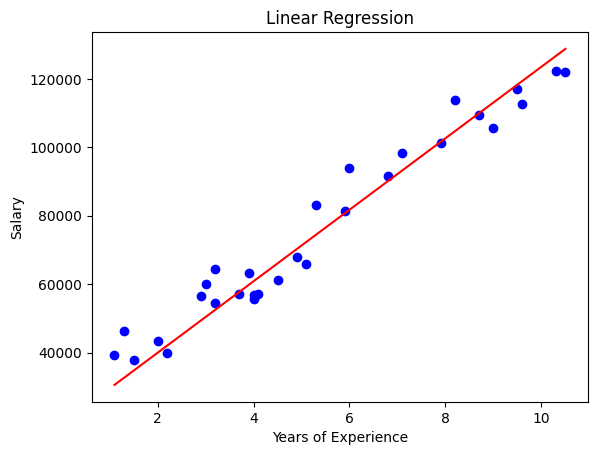

In [136]:
x_values = df_sal.YearsExperience
plt.scatter(df_sal.YearsExperience, df_sal.Salary, color="blue")
plt.plot(x_values, [m * x + b for x in x_values], color="red")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")

plt.show()

In [137]:
loss = loss_function(m, b, df_sal)
print("Final MSE:", loss)

Final MSE: 40996901.98424799


In [138]:
df_sal["PredictedSalary"] = (
    m * df_sal["YearsExperience"] + b
)

df_sal["Error"] = (
    df_sal["Salary"] - df_sal["PredictedSalary"]
)

df_sal.head()

,YearsExperience,Salary,PredictedSalary,Error
0,1.1,39343,30574.612225,8768.387775
1,1.3,46205,32663.675826,13541.324174
2,1.5,37731,34752.739428,2978.260572
3,2.0,43525,39975.398431,3549.601569
4,2.2,39891,42064.462033,-2173.462033
